In [ ]:
!pip install -q tensorflow keras keras-cv tensorflow-datasets matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 11.5 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import keras
import keras_cv
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
print(list(keras_cv.models.YOLOV8Detector.presets.keys()))

['resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152', 'resnet18_v2', 'resnet34_v2', 'resnet50_v2', 'resnet101_v2', 'resnet152_v2', 'mobilenet_v3_small', 'mobilenet_v3_large', 'csp_darknet_tiny', 'csp_darknet_s', 'csp_darknet_m', 'csp_darknet_l', 'csp_darknet_xl', 'efficientnetv1_b0', 'efficientnetv1_b1', 'efficientnetv1_b2', 'efficientnetv1_b3', 'efficientnetv1_b4', 'efficientnetv1_b5', 'efficientnetv1_b6', 'efficientnetv1_b7', 'efficientnetv2_s', 'efficientnetv2_m', 'efficientnetv2_l', 'efficientnetv2_b0', 'efficientnetv2_b1', 'efficientnetv2_b2', 'efficientnetv2_b3', 'densenet121', 'densenet169', 'densenet201', 'efficientnetlite_b0', 'efficientnetlite_b1', 'efficientnetlite_b2', 'efficientnetlite_b3', 'efficientnetlite_b4', 'yolo_v8_xs_backbone', 'yolo_v8_s_backbone', 'yolo_v8_m_backbone', 'yolo_v8_l_backbone', 'yolo_v8_xl_backbone', 'vitdet_base', 'vitdet_large', 'vitdet_huge', 'videoswin_tiny', 'videoswin_small', 'videoswin_base', 'resnet50_imagenet', 'resnet50_v2_imagenet

In [ ]:
detector = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

print("Model loaded successfully")

Model loaded successfully


In [ ]:
import tensorflow_datasets as tfds
import numpy as np

dataset, info = tfds.load("voc/2012", split="validation", with_info=True)

class_names = info.features["objects"]["label"].names

images = []
true_labels = []
used_classes = set()

for sample in tfds.as_numpy(dataset):

    img = sample["image"]
    labels = sample["objects"]["label"]

    if len(labels) == 0:
        continue

    for lab in labels:
        label_name = class_names[int(lab)]

        if label_name not in used_classes:
            used_classes.add(label_name)
            images.append(img)
            true_labels.append(label_name)
            break

    if len(images) == 5:
        break

print("Selected classes:", true_labels)
print("Number of images:", len(images))

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating test examples...: 0 examples [00:00, ? examples/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2012/incomplete.JGAXXY_5.0.0/voc-train.tfrecord*...:   0%|          | …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2012/incomplete.JGAXXY_5.0.0/voc-validation.tfrecord*...:   0%|       …

Dataset voc downloaded and prepared to /root/tensorflow_datasets/voc/2012/5.0.0. Subsequent calls will reuse this data.
Selected classes: ['bicycle', 'cat', 'bus', 'bird', 'car']
Number of images: 5


In [7]:
inference_resizing = keras_cv.layers.Resizing(
    640,
    640,
    pad_to_aspect_ratio=True,
    bounding_box_format="xywh"
)

resized_images = []

for img in images:
    img = tf.convert_to_tensor(img)
    img = inference_resizing(img)
    resized_images.append(img)

resized_images = tf.stack(resized_images)

print(resized_images.shape)

(5, 640, 640, 3)


In [8]:
predictions = detector.predict(resized_images, verbose=0)

boxes = predictions["boxes"]
classes = predictions["classes"]
scores = predictions["confidence"]

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_predictions(image, boxes, classes, scores, threshold=0.3):

    fig, ax = plt.subplots(1, figsize=(8,8))
    ax.imshow(image.astype("uint8"))
    ax.axis("off")

    for box, cls, score in zip(boxes, classes, scores):

        if score < threshold:
            continue

        x, y, w, h = box

        rect = patches.Rectangle(
            (x,y),
            w,
            h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)

        label = class_names[int(cls)]

        ax.text(
            x,
            y-5,
            f"{label}: {score:.2f}",
            color="white",
            bbox=dict(facecolor="red", alpha=0.7)
        )

    plt.show()

Image 1


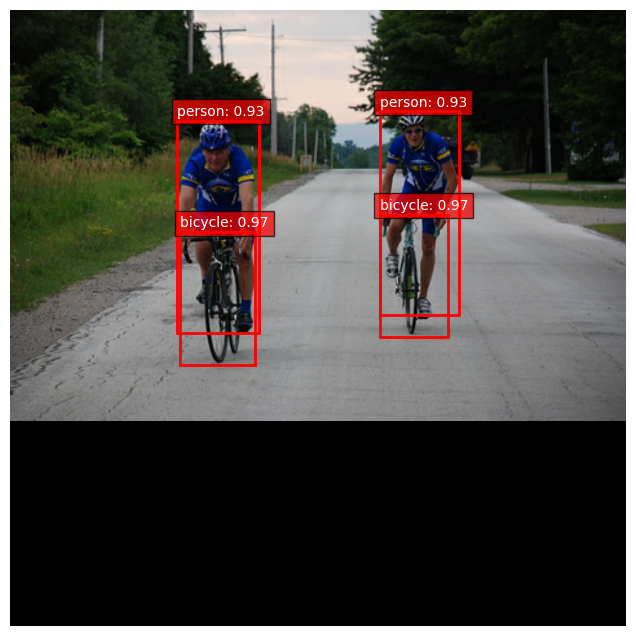

Image 2


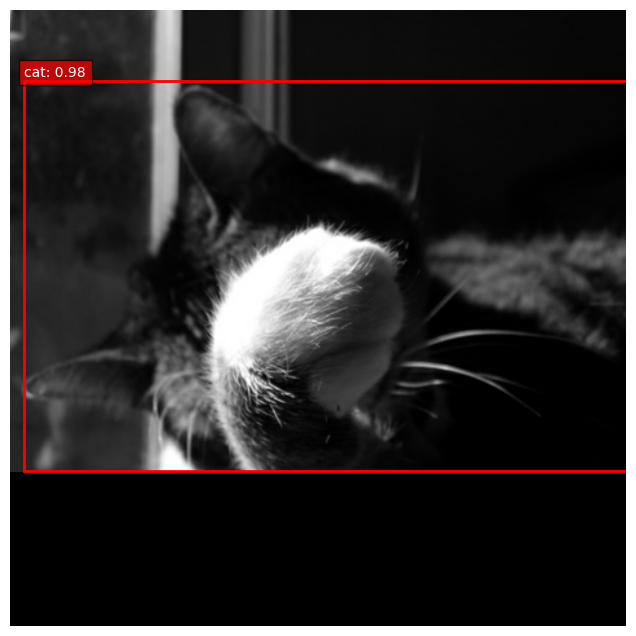

Image 3


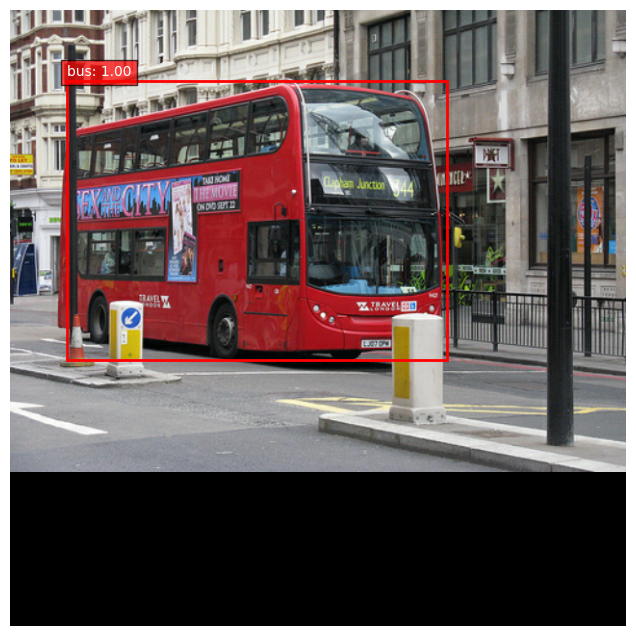

Image 4


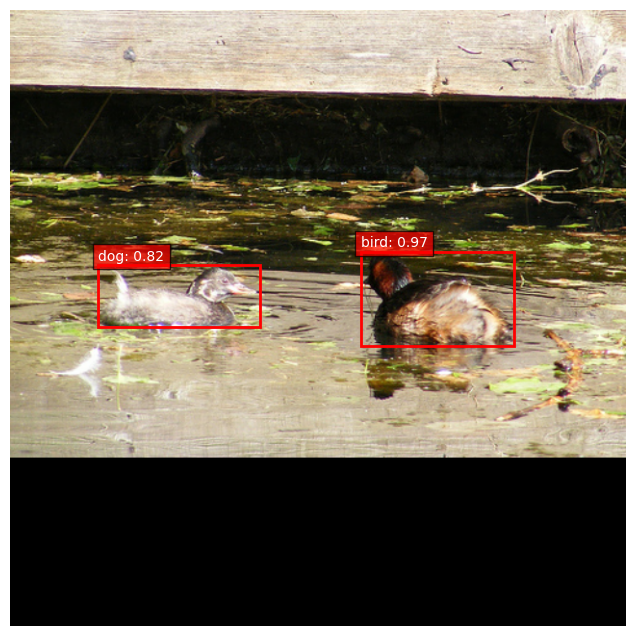

Image 5


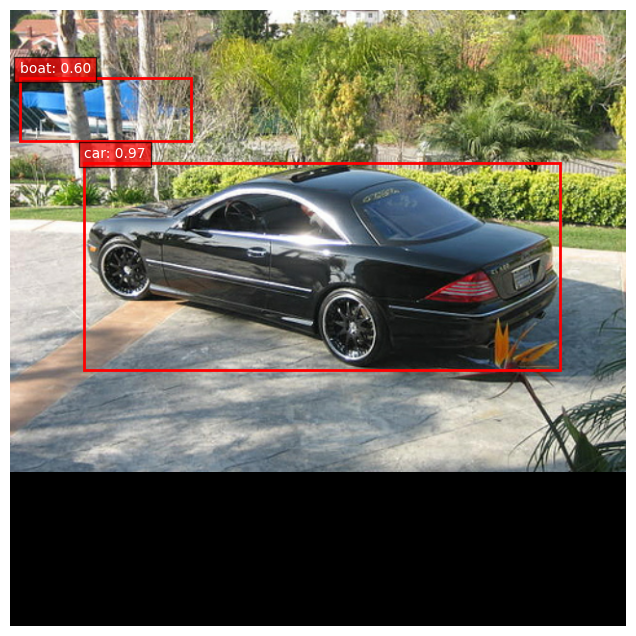

In [10]:
for i in range(5):
    print("Image", i+1)
    show_predictions(resized_images[i].numpy(), boxes[i], classes[i], scores[i])

| Image   | Objects Detected Correctly | Confidence Scores           | Missed / Incorrect Objects       |
| ------- | -------------------------- | --------------------------- | -------------------------------- |
| Image 1 | Person, Bicycle            | Person: 0.93, Bicycle: 0.97 | None                             |
| Image 2 | Cat                        | Cat: 0.98                   | None                             |
| Image 3 | Bus                        | Bus: 1.00                   | None                             |
| Image 4 | Bird                       | Bird: 0.97                  | Dog detected incorrectly (0.82)  |
| Image 5 | Car                        | Car: 0.97                   | Boat detected incorrectly (0.60) |
